# Báo cáo Phân tích Khám phá (EDA) – Dự đoán Customer Churn
---
**Mô tả dự án:**  
Dự án thực hiện Phân tích Khám phá Dữ liệu (EDA) chuyên sâu cho bài toán dự báo tỷ lệ rời bỏ dịch vụ của khách hàng (Customer Churn), dựa trên bộ dữ liệu tổng hợp từ Kaggle Playground Series, là chuỗi các cuộc thi Machine Learning hàng tháng do Kaggle tổ chức, với vai trò như một "sân tập" (Playground) để cộng đồng cọ xát và mài dũa kỹ năng.

**Mục tiêu chính:**  
- Kiểm tra chất lượng dữ liệu: Rà soát dữ liệu khuyết thiếu (missing values), dữ liệu trùng lặp và cấu trúc của tập dữ liệu gốc.
- Đánh giá mức độ mất cân bằng: Phân tích tỷ lệ của biến mục tiêu (`Churn`) để có phương án chia tập huấn luyện/kiểm thử hợp lý.
- Khám phá các đặc trưng: Dùng biểu đồ và ma trận tương quan để tìm ra những yếu tố có ảnh hưởng lớn nhất đến quyết định rời đi của khách hàng
- So sánh tập Train và Test: Đối chiếu phân phối giữa hai tập dữ liệu nhằm đảm bảo tính đồng nhất, tránh hiện tượng trôi dạt dữ liệu (data drift) khi chạy mô hình.

**Định hướng kết quả:**  
Cung cấp các kết luận phân tích cụ thể để định hình chiến lược tiền xử lý dữ liệu (preprocessing), thiết kế đặc trưng (feature engineering) và xây dựng mô hình học máy đạt hiệu quả tối ưu nhất.

---

## Các thành viên nhóm 14
| Tên          | Mã số sinh viên    |
|----------------|--------------|
| Nguyễn Lan Anh       | 24280006      |
| Lê Văn Đức (Trưởng nhóm) | 24280010|
| Trần Quang Huy| 24280015|
| Phạm Tiến Phát    | 24280018 | 
|    Hoàng Gia Bảo | 24280049      |
| Đặng Hoàng Khang| 24280076|
| Nguyễn Tiến Phát | 24280093|

## 0. Setup môi trường làm việc (Environment Setup)

### 0.1 Import thư viện (Library Imports)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import matplotlib.ticker as mtick

In [2]:
from IPython.display import display
from scipy.stats import chi2_contingency

### 0.2 Cấu hình hiển thị và đồ thị (Display & Styling Configuration)

In [3]:
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid")

### 0.3 Tải dữ liệu cần thiết (Data Loading)

In [ ]:
print("Đang tải dữ liệu từ Kaggle...")
path = kagglehub.competition_download("playground-series-s6e3")

df_train = pd.read_csv(os.path.join(path, 'train.csv'))
df_test = pd.read_csv(os.path.join(path, 'test.csv'))

print("✅ Tải dữ liệu thành công!")
print(f"Kích thước tập Train: {df_train.shape}")
print(f"Kích thước tập Test: {df_test.shape}")

Đang tải dữ liệu từ Kaggle...
✅ Tải dữ liệu thành công!
Kích thước tập Train: (594194, 21)
Kích thước tập Test: (254655, 20)


In [5]:
df_train_copy = df_train.copy()

In [6]:
df_train_copy.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1000,1653.8500,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5000,3778.2000,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4000,5841.3500,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.7000,70.7000,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.4500,70.4500,Yes


In [38]:
df_test_copy = df_test.copy()

In [39]:
df_test_copy.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.5500,8061.5000
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.8000,1336.5000
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.5500,633.5500
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.1000,6457.1500
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.3500,1233.6500


## 1. Tiền xử lí dữ liệu training (Data Preprocessing)

**Tiền xử lí dữ liệu: Thông qua các bước dưới đây để làm sạch và chuẩn hóa dữ liệu** 
1. Kiểm tra dữ liệu rỗng (Completeness Check)
2. Kiểm tra tính trùng lặp (Validity&Consistency Check)
3. Kiểm tra tổng quan dữ liệu (Overview)  


In [35]:
print("1. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):")
if df_train_copy.isnull().sum().sum() == 0:
    print("Không có dữ liệu rỗng trong tập dữ liệu.")
else:
    print("Tồn tại dữ liệu rỗng trong tập dữ liệu, cụ thể:")
    print(df_train_copy.isnull().sum())

1. KIỂM TRA DỮ LIỆU RỖNG (COMPLETENESS CHECK):
Không có dữ liệu rỗng trong tập dữ liệu.


In [36]:
print("2. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):")
if df_train_copy.duplicated().sum() == 0:
    print("Không có dữ liệu trùng lặp trong tập dữ liệu.")
else:
    print("Tồn tại", df_train.duplicated().sum(), "hàng dữ liệu trùng lặp trong tập dữ liệu.")


2. KIỂM TRA TÍNH TRÙNG LẶP (VALIDITY & CONSISTENCY CHECK):
Không có dữ liệu trùng lặp trong tập dữ liệu.


In [37]:
print("3. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):")
df_train_copy.info()

3. KIỂM TRA TỔNG QUAN DỮ LIỆU (DATA OVERVIEW):
<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  object 
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-nul

## 2. Mô tả dữ liệu training (Training Dataset Overview)

### 2.1 Mô tả sơ bộ (Preliminary Overview)

| Cột | Kiểu dữ liệu | Mô tả |
| :--- | :--- | :--- |
| `id` | int64 | Mã định danh của khách hàng |
| `gender` | object | Giới tính |
| `SeniorCitizen` | int64 | Khách hàng có là người cao tuổi (>= 65 tuổi)? (`1`: Có, `0`: Không)|
| `Partner` | object | Khách hàng có sống chung với vợ/chồng?|
| `Dependents` | object | Khách hàng có cần được chăm sóc?|
| `tenure` | int64 | **Thời gian sử dụng dịch vụ:** Thời gian khách hàng đã gắn bó và sử dụng dịch vụ, tính theo tháng|
| `PhoneService` | object | Khách hàng có đăng ký dịch vụ điện thoại?|
| `MultipleLines` | object | Khách hàng có sử dụng nhiều đường dây điện thoại cùng lúc?|
| `InternetService` | object | Loại dịch vụ Internet mà khách hàng đang dùng|
| `OnlineSecurity` | object | Khách hàng có đăng ký gói bảo mật mạng trực tuyến?|
| `OnlineBackup` | object | Khách hàng có đăng ký gói sao lưu dữ liệu đám mây?|
| `DeviceProtection` | object | Khách hàng có mua gói bảo vệ thiết bị?|
| `TechSupport` | object | Khách hàng có đăng ký dịch vụ hỗ trợ kỹ thuật?|
| `StreamingTV` | object | Khách hàng có sử dụng Internet để xem truyền hình?|
| `StreamingMovies` | object | Khách hàng có sử dụng Internet để xem phim trực tuyến?|
| `Contract` | object | Loại hợp đồng thanh toán khách hàng đã ký?|
| `PaperlessBilling` | object | Khách hàng có nhận hóa đơn điện tử?|
| `PaymentMethod` | object | Phương thức thanh toán|
| `MonthlyCharges` | float64 | **Cước phí tháng**|
| `TotalCharges` | float64 | **Tổng cước phí**|
| `Churn` | object | **Biến mục tiêu (Target):** Khách hàng có rời bỏ dịch vụ không?|

In [10]:
df_train_copy['SeniorCitizen'] = df_train_copy['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

**Note:** Đưa biến SeniorCitizen về hai giá trị Yes/No thay cho 1/0 như trong dữ liệu gốc để đồng nhất so với các biến trả về 2 giá trị Yes/No khác.

### 2.2 Phân loại biến (Feature Classification)
Các biến được phân loại dựa trên đặc điểm của chúng để đưa vào 4 nhóm phân biệt:
- Biến định danh (Identifiers)
- Biến định tính (Categorical Features)
- Biến định lượng (Numerical Features)
- Biến mục tiêu (Target): Là mục tiêu của dự án này, biến `Churn`


In [11]:
identifier_data= df_train_copy['id']
identifier_features = [identifier_data.name]

print(f'Có {len(identifier_features)} biến định danh:','\n')
print(identifier_features)


Có 1 biến định danh: 

['id']


In [12]:
categorical_data=df_train_copy.select_dtypes(include=['object','str']).drop('Churn', axis=1, errors='ignore')
categorical_features=categorical_data.columns.tolist()

print(f'Có {len(categorical_features)} biến định tính:','\n')
print(categorical_features)

Có 16 biến định tính: 

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [13]:
numerical_data = df_train_copy.select_dtypes(include='number').drop('id', axis=1, errors='ignore')
numerical_features = numerical_data.columns.tolist()

print(f'Có {len(numerical_features)} biến định lượng:\n')
print(numerical_features)

Có 3 biến định lượng:

['tenure', 'MonthlyCharges', 'TotalCharges']


In [14]:
target_data = df_train_copy['Churn']        
target_features = [target_data.name]
print(f'Có {len(target_features)} biến mục tiêu:','\n')
print(target_features)

Có 1 biến mục tiêu: 

['Churn']


## 3. Mô tả và trực quan hóa các đặc trưng (Feature Analysis & Visualization)

**Mô tả, trực quan hóa các biến định tính và biến định lượng, để chuẩn bị cho phần so sánh tương quan(Correlation) giữa các biến này và biến mục tiêu là `Churn`.**

### 3.1 Biến định lượng (Numerical Features)

**Phân tích tổng quan các biến định lượng**

In [15]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,594194.0000,36.5773,25.0619,1.0000,12.0000,35.0000,62.0000,72.0000
MonthlyCharges,594194.0000,65.8662,31.0674,18.2500,29.9000,74.1000,90.8000,118.7500
TotalCharges,594194.0000,2494.3771,2353.9167,18.8000,639.6500,1433.6500,4263.8000,8684.8000


**Note:** Không xuất hiện những giá trị không hợp lệ, có thể kể đến như các giá trị âm ở `MonthlyCharges`,`TotalCharges` và `tenure`.

In [16]:
numerical_data.var()

tenure               628.0999
MonthlyCharges       965.1861
TotalCharges     5540923.8793
dtype: float64

**Note:** Phương sai của các biến định lượng, có thể thấy dữ liệu phân bố khá rộng.

In [17]:
numerical_data.skew()

tenure            0.0631
MonthlyCharges   -0.2895
TotalCharges      0.9092
dtype: float64

**Note:** Về tổng quan, dữ liệu phân bố khá đối xứng, ít bị lệch.

**Trực quan hóa các biến định lượng bằng đồ thị Histogram để quan sát phân bố**

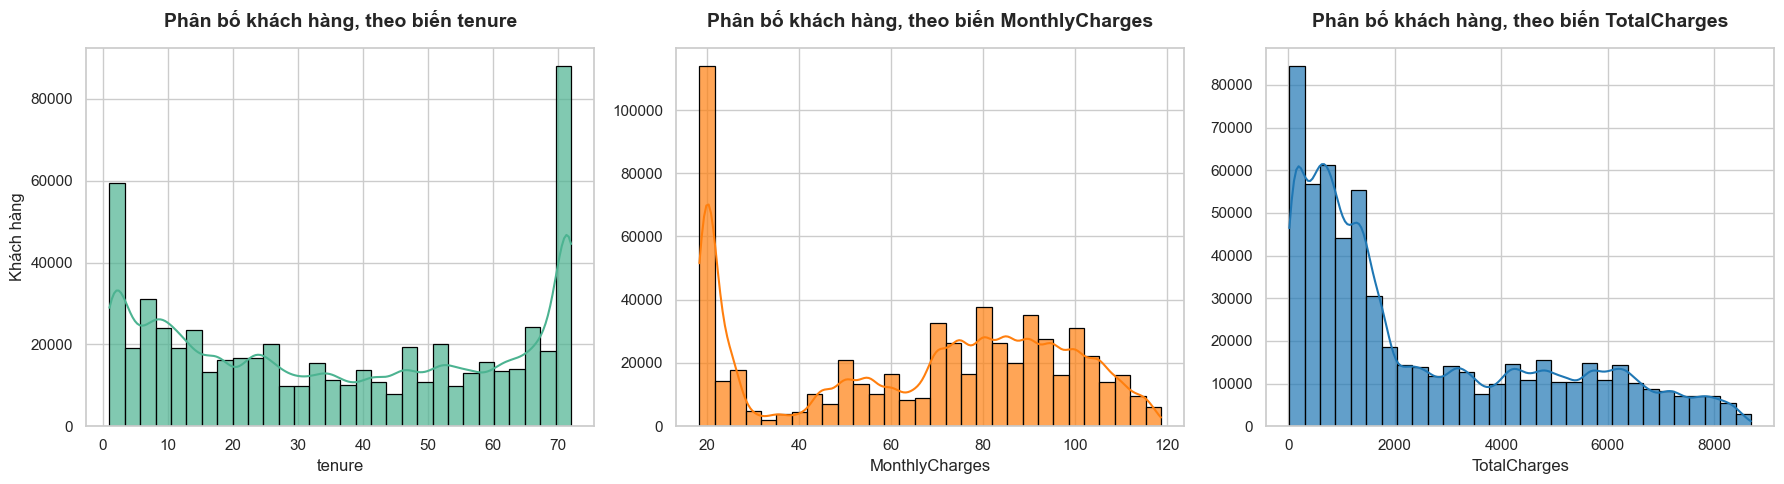

In [18]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
colors = ['#4CB391', '#FF7F0E', '#1F77B4'] 

for i, col in enumerate(numerical_features):
    sns.histplot(data=df_train_copy, x=col, ax=axes[i], bins=30, kde=True, color=colors[i], edgecolor='black', alpha=0.7)
    
    axes[i].set_title(f'Phân bố khách hàng, theo biến {col}', fontsize=14, fontweight='bold', pad=15)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Khách hàng' if i == 0 else '', fontsize=12)
plt.tight_layout()
plt.show()

**Note:** Trực quan hóa phân bố khách hàng theo các biến định lượng, tính trên đầu người.

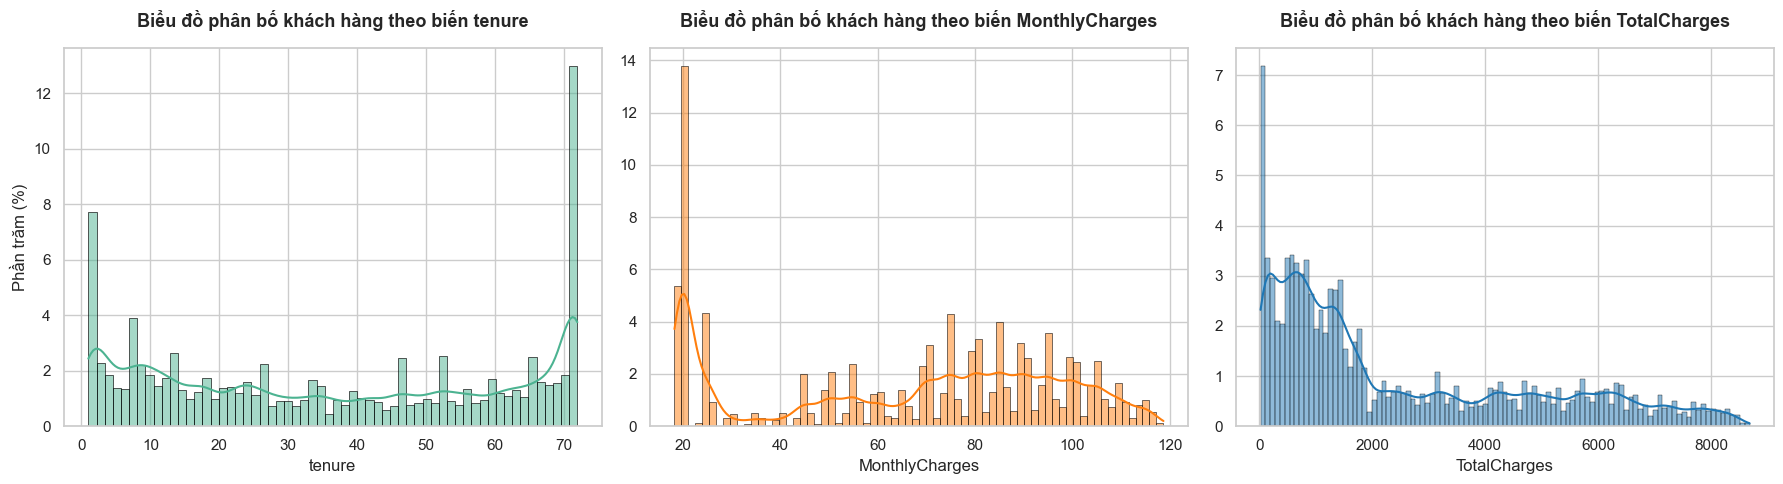

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

colors = ['#4CB391', '#FF7F0E', '#1F77B4'] 

for i, col in enumerate(numerical_features):
    sns.histplot(
        data=df_train_copy, 
        x=col, 
        ax=axes[i], 
        color=colors[i], 
        stat='percent', 
        kde=True, 
        alpha=0.5, 
        edgecolor='black'
    )
    
    axes[i].set_title(f'Biểu đồ phân bố khách hàng theo biến {col}', fontsize=13, fontweight='bold', pad=15)
    axes[i].set_xlabel(col, fontsize=12)
    
    if i == 0:
        axes[i].set_ylabel('Phần trăm (%)', fontsize=12)
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

**Note:** Trực quan hóa phân bố khách hàng theo các biến định lượng, tính trên phần trăm(%).

In [20]:
numerical_data.nunique()

tenure               72
MonthlyCharges     1921
TotalCharges      31910
dtype: int64

**Note:**
- Biến `tenture` chỉ thời gian sử dụng dịch vụ, tính theo tháng, là các giá trị nguyên dương nên chỉ phân bố trong khoảng nhỏ xác định.
- Biến `MonthlyCharges`,`TotalCharges` là cước phí theo tháng và tổng cước phí nên phân bố rất rộng.

**Trực quan hóa các biến định lượng bằng đồ thị boxplot để tìm và loại bỏ các giá trị ngoại lai (Outliners)**

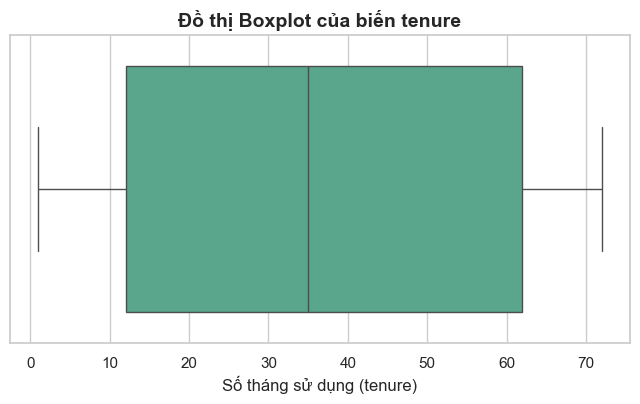

In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_train_copy, x='tenure', color='#4CB391')
plt.title('Đồ thị Boxplot của biến tenure', fontsize=14, fontweight='bold')
plt.xlabel('Số tháng sử dụng (tenure)', fontsize=12)
plt.show()

**Note:** Không có điểm ngoại lai (Outliner) nào được phát hiện khi xét biến định lượng `tenure`, tất cả dữ liệu đều nằm trong khoảng không chứa giá trị ngoại lệ (non-outlier range).

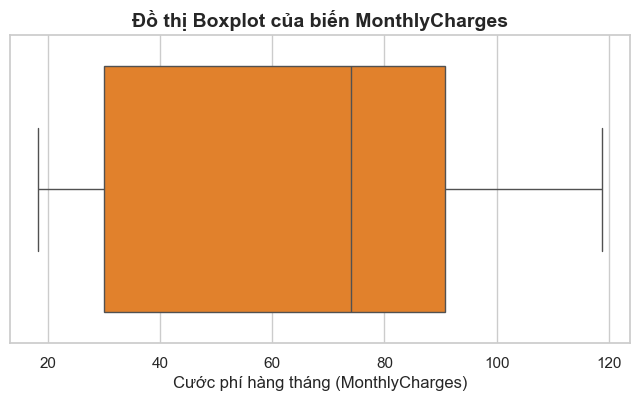

In [22]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_train_copy, x='MonthlyCharges', color='#FF7F0E')
plt.title('Đồ thị Boxplot của biến MonthlyCharges', fontsize=14, fontweight='bold')
plt.xlabel('Cước phí hàng tháng (MonthlyCharges)', fontsize=12)
plt.show()

**Note:** Không có điểm ngoại lai (Outliner) nào được phát hiện khi xét biến định lượng `MonthlyCharges`, tất cả dữ liệu đều nằm trong khoảng không chứa giá trị ngoại lệ (non-outlier range).

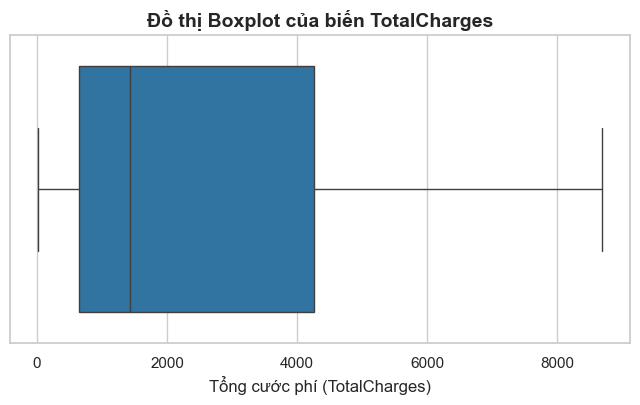

In [23]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_train_copy, x='TotalCharges', color='#1F77B4')
plt.title('Đồ thị Boxplot của biến TotalCharges', fontsize=14, fontweight='bold')
plt.xlabel('Tổng cước phí (TotalCharges)', fontsize=12)
plt.show()

**Note:** Không có điểm ngoại lai (Outliner) nào được phát hiện khi xét biến định lượng `TotalCharges`, tất cả dữ liệu đều nằm trong khoảng không chứa giá trị ngoại lệ (non-outlier range).

**Kết luận: Không có giá trị ngoại lai nào xuất hiện nên không thực hiện loại bỏ các dữ liệu ngoại lai.**

### 3.2 Biến định tính (Categorical Features)

**Phân tích tổng quan các biến định tính**

In [24]:
unique_counts = categorical_data.nunique()
print("Số lượng giá trị phân biệt tương ứng với từng biến định tính:")
for index, (col, count) in enumerate(unique_counts.items(), start=1):
    print(f"{index}. '{col}' có {count} giá trị phân biệt")

Số lượng giá trị phân biệt tương ứng với từng biến định tính:
1. 'gender' có 2 giá trị phân biệt
2. 'SeniorCitizen' có 2 giá trị phân biệt
3. 'Partner' có 2 giá trị phân biệt
4. 'Dependents' có 2 giá trị phân biệt
5. 'PhoneService' có 2 giá trị phân biệt
6. 'MultipleLines' có 3 giá trị phân biệt
7. 'InternetService' có 3 giá trị phân biệt
8. 'OnlineSecurity' có 3 giá trị phân biệt
9. 'OnlineBackup' có 3 giá trị phân biệt
10. 'DeviceProtection' có 3 giá trị phân biệt
11. 'TechSupport' có 3 giá trị phân biệt
12. 'StreamingTV' có 3 giá trị phân biệt
13. 'StreamingMovies' có 3 giá trị phân biệt
14. 'Contract' có 3 giá trị phân biệt
15. 'PaperlessBilling' có 2 giá trị phân biệt
16. 'PaymentMethod' có 4 giá trị phân biệt


**Note:** Phân tích sơ bộ để tìm ra số giá trị phân biệt ứng với từng biến định tính.

In [25]:
high_cardinality_cols = [col for col in categorical_data.select_dtypes(include=['object','str']).columns if categorical_data[col].nunique() > 10]
low_cardinality_cols = [col for col in categorical_data.select_dtypes(include=['object','str']).columns if categorical_data[col].nunique() <= 10]

if len(high_cardinality_cols) == 0:
    print("Không có biến định tính nào có nhiều hơn 10 giá trị phân biệt.")
else:
    print(f"Có {len(high_cardinality_cols)} biến định tính có nhiều hơn 10 giá trị phân biệt:")
    for col in high_cardinality_cols:
        print(f" - {col}")

Không có biến định tính nào có nhiều hơn 10 giá trị phân biệt.


**Note:** Thực hiện phân loại các loại biến định tính thành
- Biến có độ phân nhánh thấp(Low-cardinality Variables), có nhiều nhất 10 giá trị phân biệt
- Biến có độ phân nhánh cao(Low-cardinality Variables), có nhiều hơn 10 giá trị phân biệt  

**Note:** Thực hiện phân loại để phục vụ cho việc trực quan hóa, có thể thấy tất cả các biến đều có độ phân nhánh thấp, cụ thể hơn ở bước dưới

In [26]:
for col in low_cardinality_cols:
    print(f"🔹 Cột: {col}")
    print(categorical_data[col].value_counts(dropna=False))
    print("-" * 50)

🔹 Cột: gender
gender
Female    298738
Male      295456
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: SeniorCitizen
SeniorCitizen
No     526395
Yes     67799
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: Partner
Partner
Yes    309554
No     284640
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: Dependents
Dependents
No     414362
Yes    179832
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: PhoneService
PhoneService
Yes    557893
No      36301
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: MultipleLines
MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64
--------------------------------------------------
🔹 Cột: InternetService
InternetService
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64
----

**Note:** 
- Hầu hết các biến định tính mang hai giá trị phân biệt là `Yes` và `No`
- Một số biến khác mang nhiều hơn hai giá trị phân biệt là `Yes` và `No`, nhưng dựa trên đặc thù, ta vẫn có thể đưa chúng về như biến trên, chẳng hạn như biến `StreamingMovies` thì nhóm  `No internet service` có thể ghép chung vào nhóm `No` vì nhóm khách hàng không có internet thật sự không có khả năng stream các bộ phim
- Các biến định tính phức tạp hơn không thể phân loại như trên được xếp vào nhóm thứ ba, nhóm biến định tính phức tạp

**Trực quan hóa các biến định tính bằng đồ thị Boxplot để quan sát phân bố**

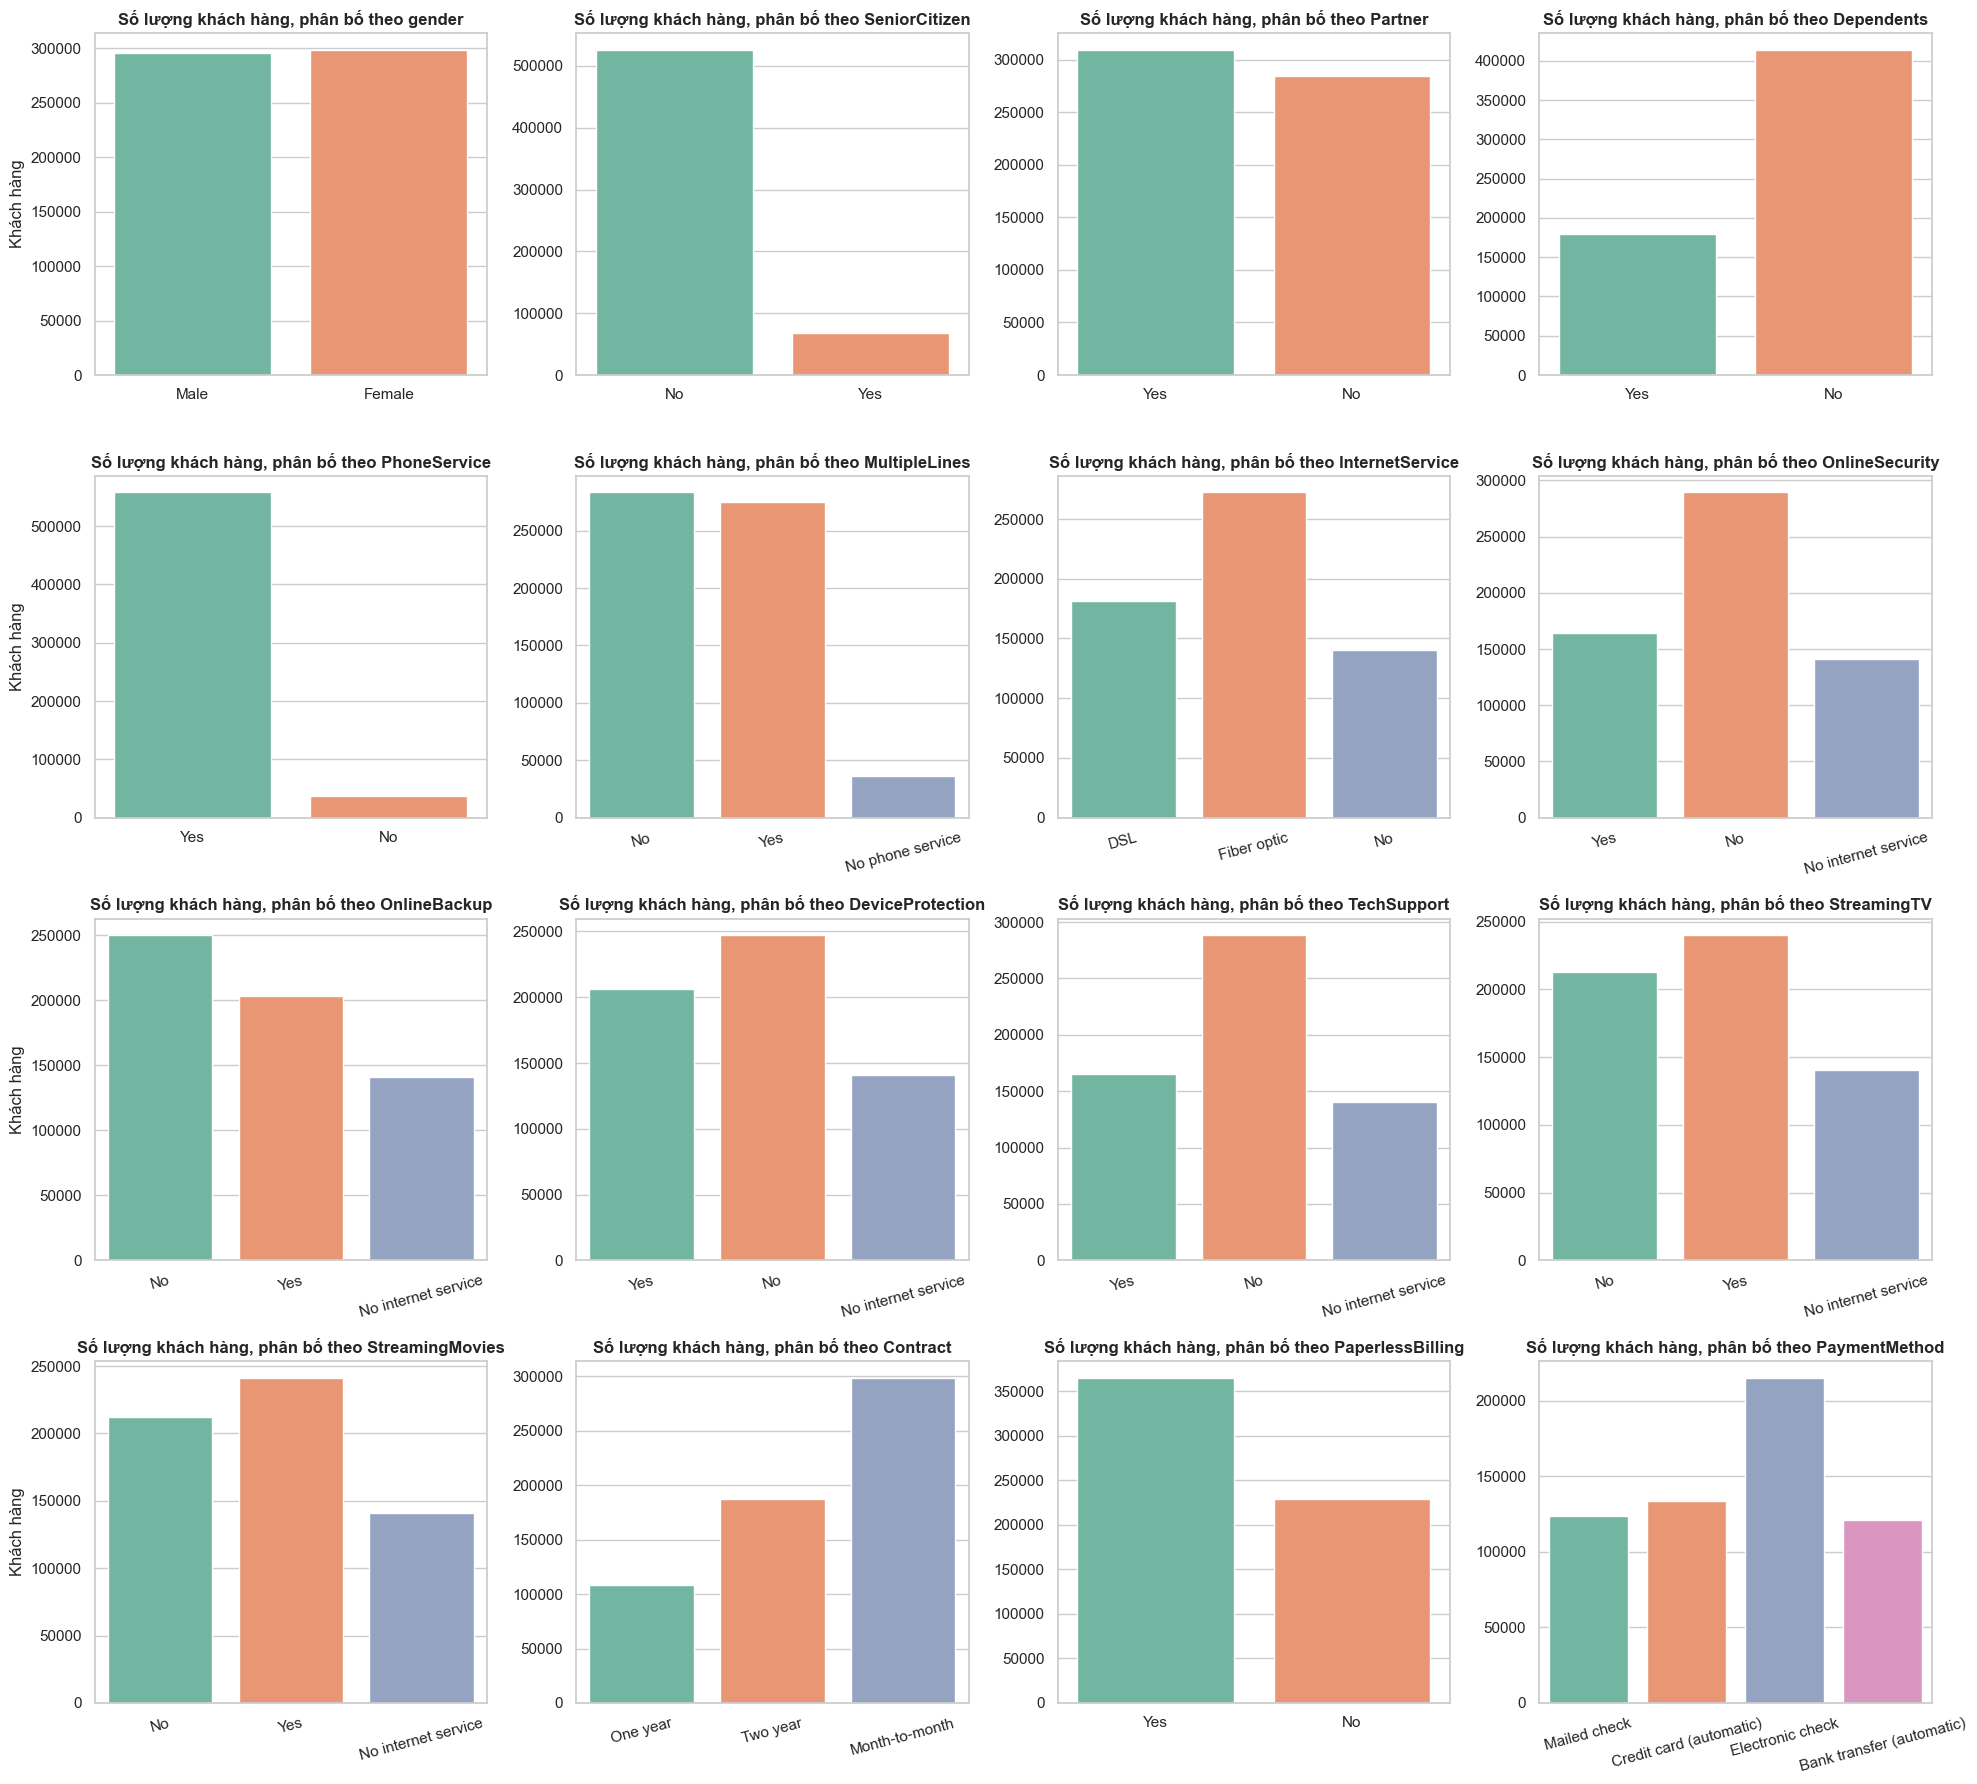

In [27]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 18))

axes = axes.flatten() 

for i, col in enumerate(categorical_features):
    sns.countplot(data=df_train_copy, x=col, hue=col, ax=axes[i], palette='Set2', legend=False)
    
    axes[i].set_title(f'Số lượng khách hàng, phân bố theo {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Khách hàng' if i % 4 == 0 else '') 
    
    if df_train_copy[col].nunique() > 2:
        axes[i].tick_params(axis='x', rotation=15)

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Note:** Trực quan hóa phân bố khách hàng theo từng biến định lượng

## 4. Phân tích tương quan (Correlation Analysis)

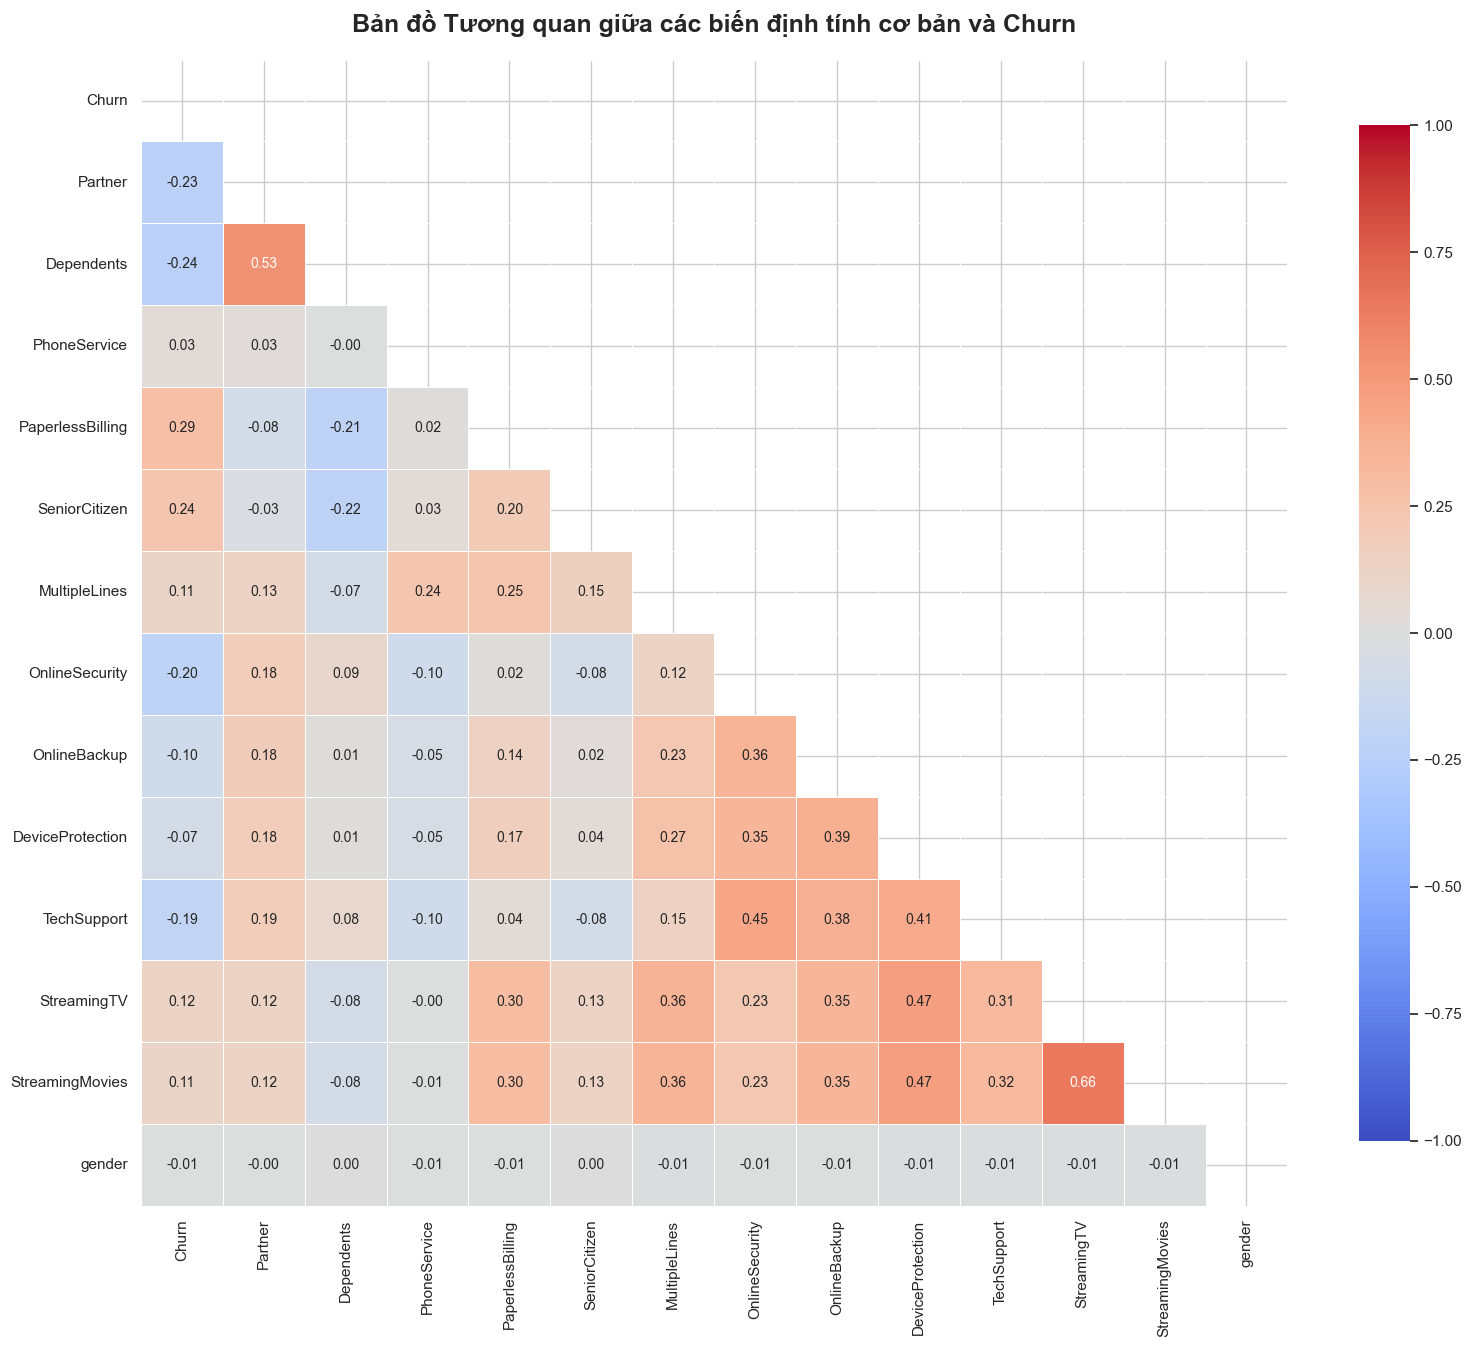

In [28]:
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'SeniorCitizen']
for col in binary_cols:
    df_train_copy[col] = df_train_copy[col].replace({'Yes': 1, 'No': 0})

df_train_copy['gender'] = df_train_copy['gender'].replace({'Male': 1, 'Female': 0})

nearly_binary_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in nearly_binary_cols:
    df_train_copy[col] = df_train_copy[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    df_train_copy[col] = df_train_copy[col].replace({'Yes': 1, 'No': 0})

cols_to_corr = binary_cols + nearly_binary_cols + ['gender']

corr_matrix = df_train_copy[cols_to_corr].astype(float).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 14))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10}
)

plt.title('Bản đồ Tương quan giữa các biến định tính cơ bản và Churn', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

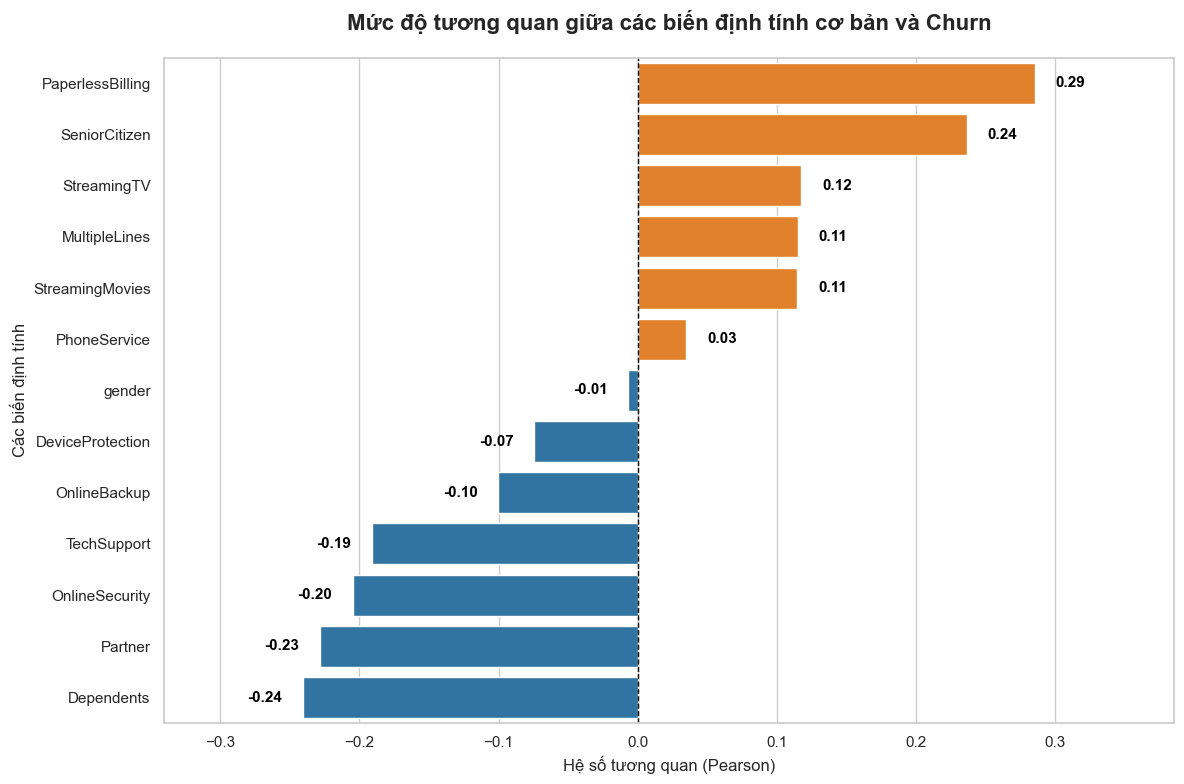

In [29]:
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(ascending=False)
colors = ['#FF7F0E' if val > 0 else '#1F77B4' for val in churn_corr.values]

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=churn_corr.values, 
    y=churn_corr.index, 
    hue=churn_corr.index,
    palette=colors,
    legend=False
)

plt.title('Mức độ tương quan giữa các biến định tính cơ bản và Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hệ số tương quan (Pearson)', fontsize=12)
plt.ylabel('Các biến định tính', fontsize=12)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

for i, val in enumerate(churn_corr.values):
    ax.text(val + (0.015 if val > 0 else -0.015), i, f'{val:.2f}', 
            va='center', ha='left' if val > 0 else 'right', 
            fontsize=11, fontweight='bold', color='black')

plt.xlim(churn_corr.min() - 0.1, churn_corr.max() + 0.1)

plt.tight_layout()
plt.show()

In [30]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    k = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * k))

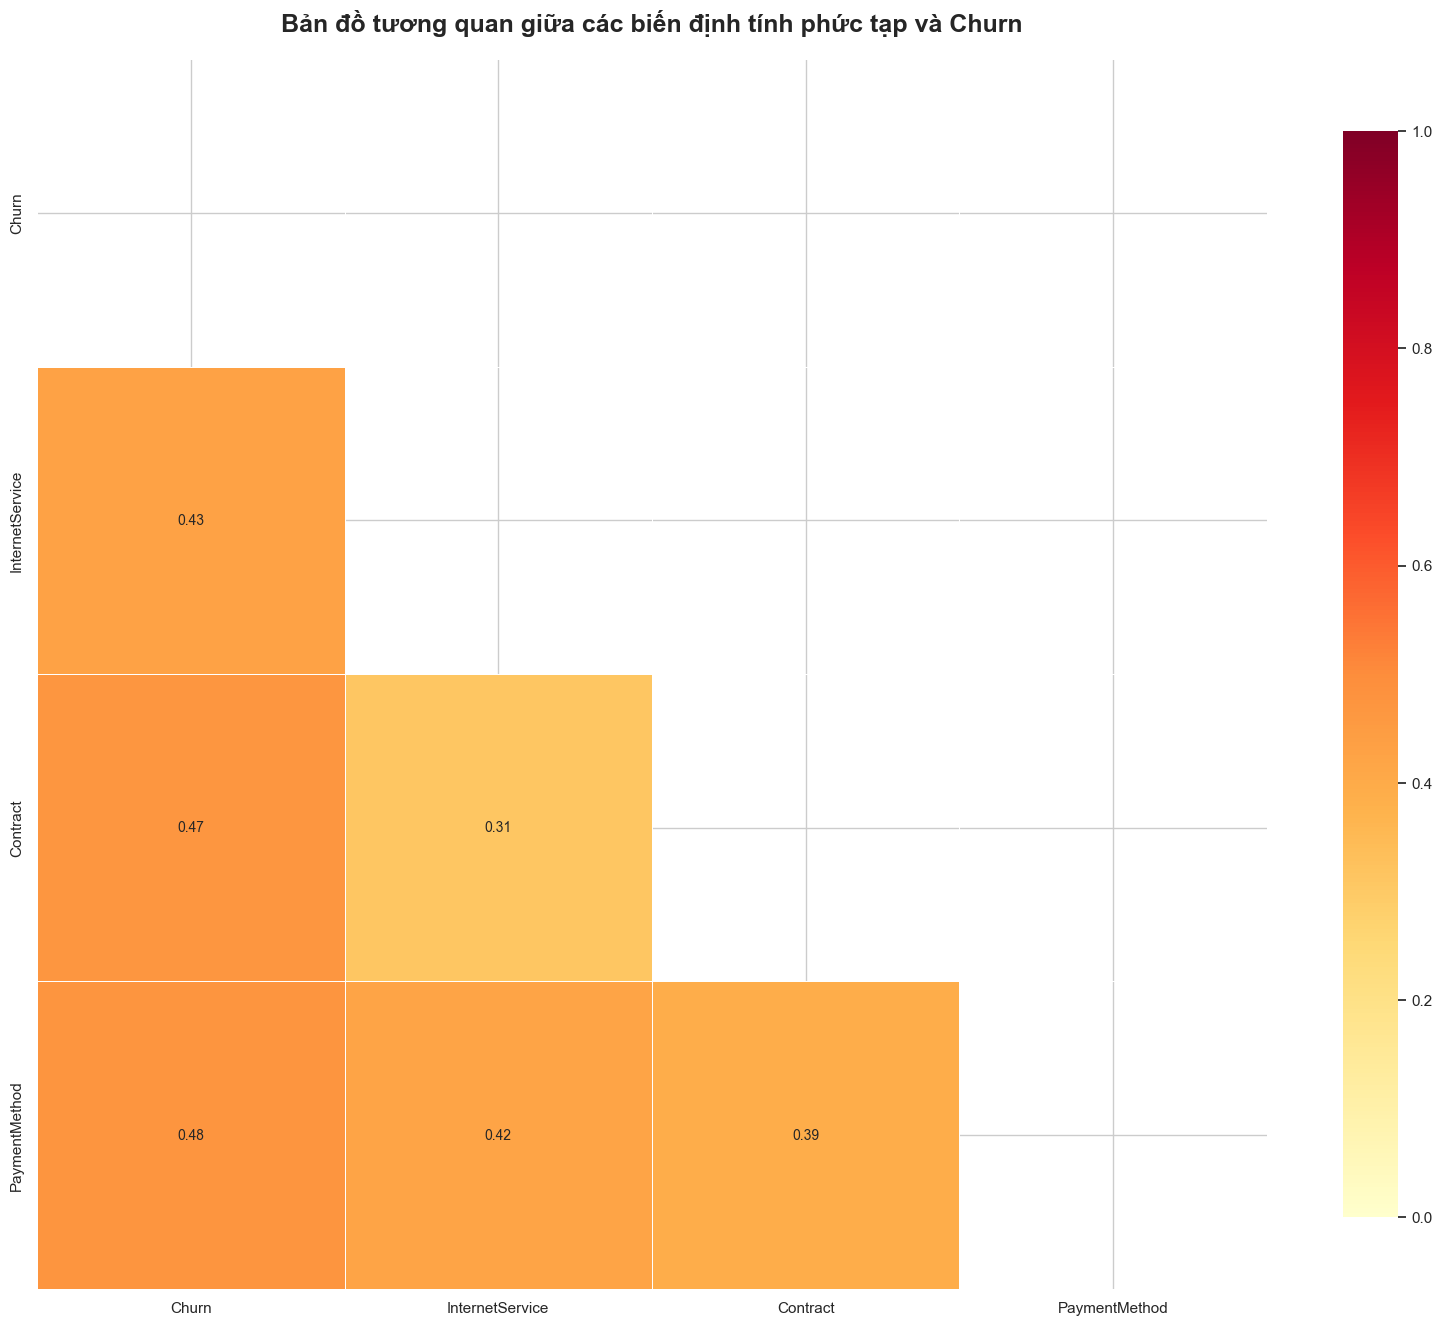

In [31]:
multi_cols = ['Churn', 'InternetService', 'Contract', 'PaymentMethod']

cramers_matrix = pd.DataFrame(index=multi_cols, columns=multi_cols, dtype=float)

for col1 in multi_cols:
    for col2 in multi_cols:
        if col1 == col2:
            cramers_matrix.loc[col1, col2] = 1.0
        else:
            cramers_matrix.loc[col1, col2] = cramers_v(
                df_train_copy[col1].astype(str),
                df_train_copy[col2].astype(str)
            )


mask = np.triu(np.ones_like(cramers_matrix, dtype=bool))
plt.figure(figsize=(16, 14))

sns.heatmap(
    cramers_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='YlOrRd',
    vmin=0, vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10}
)

plt.title("Bản đồ tương quan giữa các biến định tính phức tạp và Churn", fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

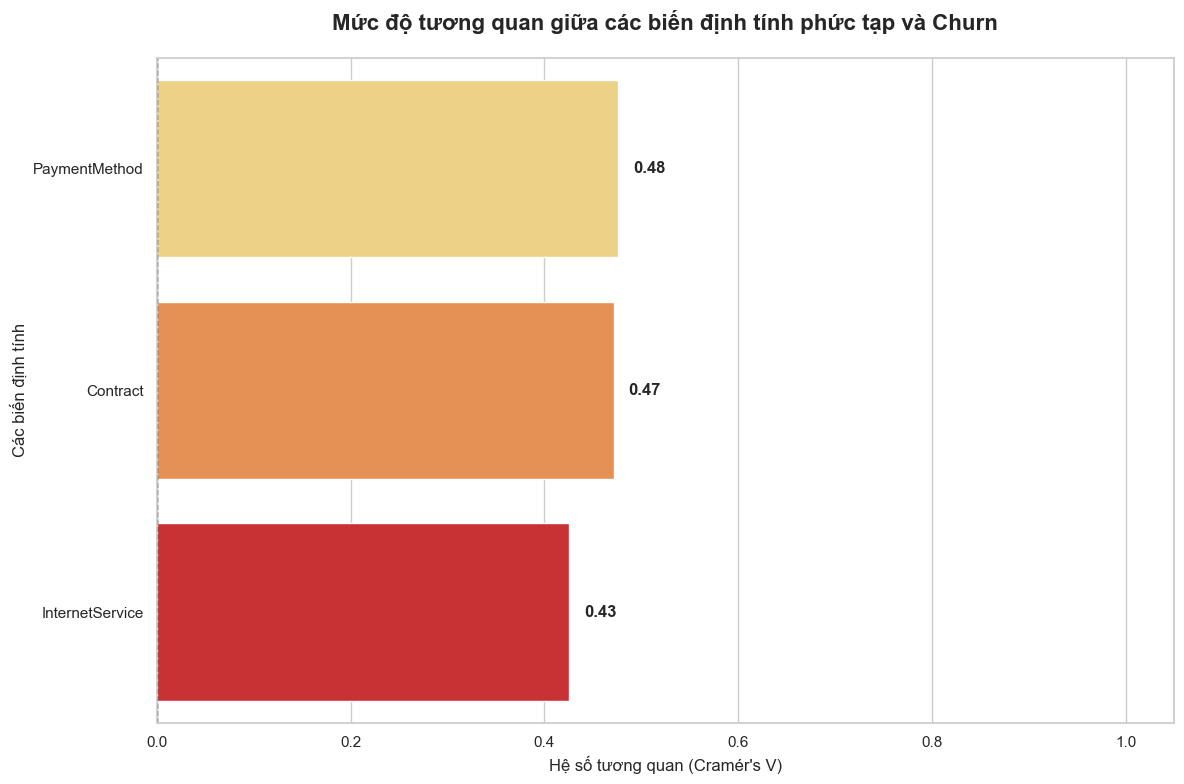

In [32]:
churn_cramers = cramers_matrix['Churn'].drop('Churn').sort_values(ascending=False)
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=churn_cramers.values,
    y=churn_cramers.index,
    hue=churn_cramers.index,
    palette='YlOrRd',
    legend=False
)


plt.title("Mức độ tương quan giữa các biến định tính phức tạp và Churn", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Hệ số tương quan (Cramér's V)", fontsize=12)
plt.ylabel('Các biến định tính', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlim(0, 1.05)

for i, val in enumerate(churn_cramers.values):
    ax.text(val + 0.015, i, f'{val:.2f}',
            va='center', ha='left', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

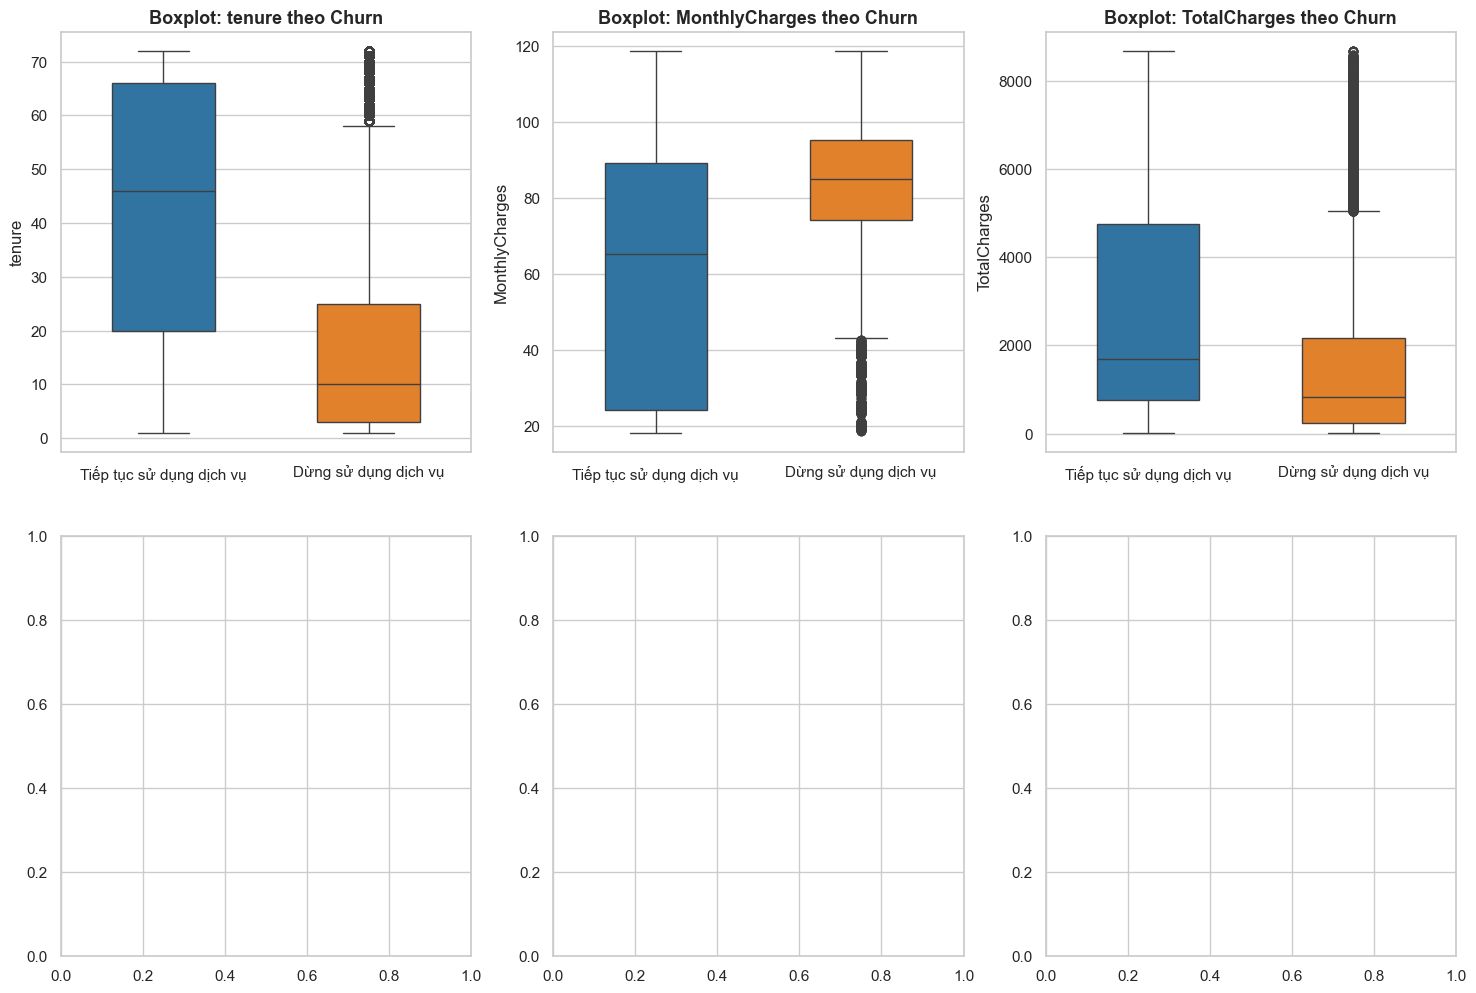

In [41]:
quant_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))


for i, col in enumerate(quant_cols):
    sns.boxplot(
        data=df_train_copy, x='Churn', y=col,
        hue='Churn',
        palette=['#1F77B4', '#FF7F0E'],
        legend=False,
        ax=axes[0, i], width=0.5
    )
    axes[0, i].set_title(f'Boxplot: {col} theo Churn', fontsize=13, fontweight='bold')
    axes[0, i].set_xlabel('')
    axes[0, i].set_xticks([0, 1])
    axes[0, i].set_xticklabels(['Tiếp tục sử dụng dịch vụ', 'Dừng sử dụng dịch vụ'])

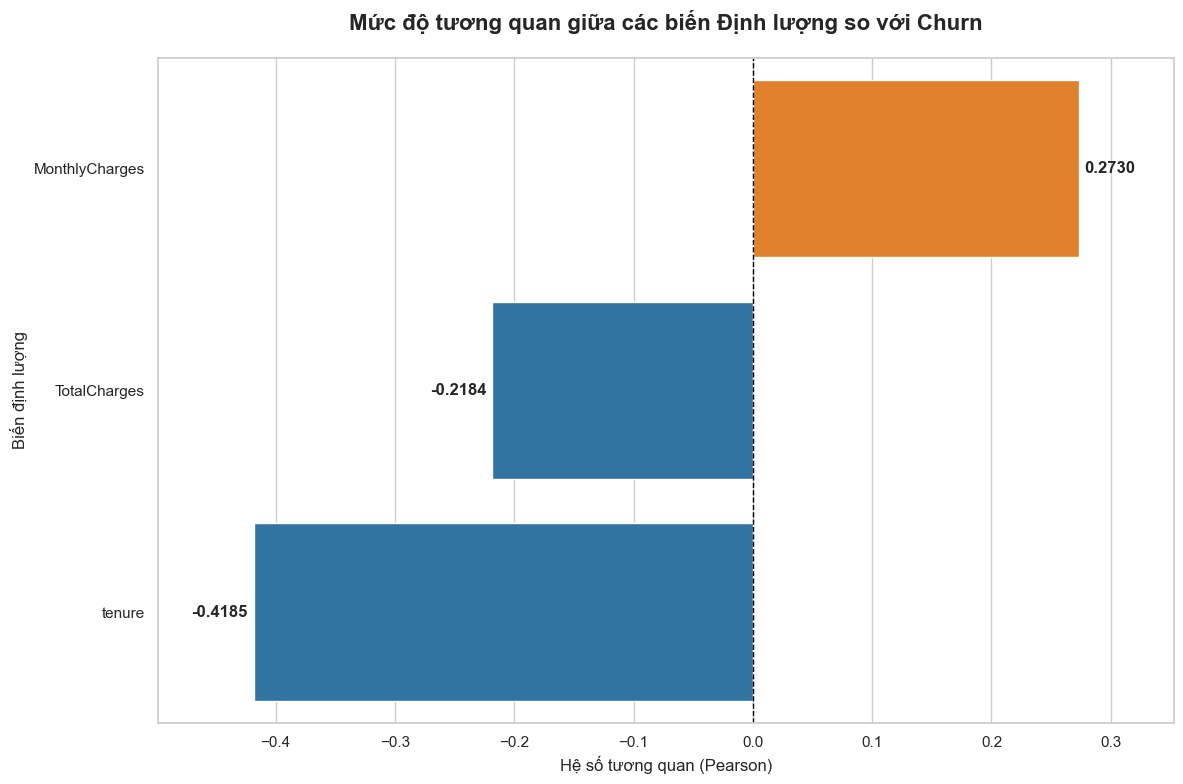

In [34]:
corr_quant = df_train_copy[quant_cols + ['Churn']].corr()['Churn'].drop('Churn').sort_values(ascending=False)

colors = ['#FF7F0E' if v > 0 else '#1F77B4' for v in corr_quant.values]

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=corr_quant.values, y=corr_quant.index,
    hue=corr_quant.index, palette=colors, legend=False
)

plt.title('Mức độ tương quan giữa các biến Định lượng so với Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hệ số tương quan (Pearson)', fontsize=12)
plt.ylabel('Biến định lượng', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

for i, val in enumerate(corr_quant.values):
    ax.text(val + (0.005 if val > 0 else -0.005), i, f'{val:.4f}',
            va='center', ha='left' if val > 0 else 'right',
            fontsize=12, fontweight='bold')

plt.xlim(corr_quant.min() - 0.08, corr_quant.max() + 0.08)
plt.tight_layout()
plt.show()